# Exploratory analysis of the data set

## Imports

In [211]:
import math

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [212]:
def plot_grid(data, cols, kind='box', target=None, n_cols=3, figsize_per=(6, 5)):
    """Plot a grid of subplots, one per column in `cols`.

    kind:
        'box'       -> distribution boxplot (y=col)
        'box_hue'   -> boxplot split by `target` (hue=target)
        'hist'      -> univariate count (x=col)
        'churn_bar' -> mean churn bar per category (y=target) + global-mean line + labels
    """
    n_rows = math.ceil(len(cols) / n_cols)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per[0] * n_cols, figsize_per[1] * n_rows),
    )
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        if kind == 'box':
            sns.boxplot(data=data, y=col, ax=ax)
        elif kind == 'box_hue':
            sns.boxplot(data=data, y=col, hue=target, ax=ax)
        elif kind == 'hist':
            sns.histplot(data=data, x=col, ax=ax)
        elif kind == 'churn_bar':
            sns.barplot(data=data, x=col, y=target, ax=ax, errorbar=None)
            ax.axhline(data[target].mean(), color='red', ls='--', lw=1)
            ax.bar_label(ax.containers[0], fmt='%.2f', fontsize=12, padding=3)
        ax.set_title(col, fontsize=18, fontweight='bold')
        ax.tick_params(axis='both', labelsize=13)
        ax.set_ylabel(ax.get_ylabel(), fontsize=14)

    # drop the empty leftover subplots
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

## Loading

In [213]:
data_path = '../data/raw/'

df = pd.read_csv(data_path+'WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.shape

(7043, 21)

In [214]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Sanity checks and cleaning

In [215]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [216]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [217]:
# Duplicate rows and customerID uniqueness
print('Duplicate rows:', df.duplicated().sum())
print('Unique customerID:', df['customerID'].nunique(), '/', len(df))

Duplicate rows: 0
Unique customerID: 7043 / 7043


`TotalCharges` is stored as a string, which does not match what the feature represents — it should be a float.

Note also that `SeniorCitizen` (0/1) is stored as an int but should be treated as categorical.

In [218]:
mask = pd.to_numeric(df['TotalCharges'],errors='coerce').isna()

df.loc[mask,'TotalCharges']

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: str

In [219]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].isna().sum()

np.int64(11)

In [220]:
df.loc[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


We now clean those nulls. Note that `tenure` is 0 for all of them, meaning these are new customers who have not made any payment yet.

In [221]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [222]:
df.loc[mask,'TotalCharges']

488     0.0
753     0.0
936     0.0
1082    0.0
1340    0.0
3331    0.0
3826    0.0
4380    0.0
5218    0.0
6670    0.0
6754    0.0
Name: TotalCharges, dtype: float64

## Distributions and outliers of the features

In [223]:
features_df = df.drop(columns = ['Churn','customerID'])

In [224]:
num_cols = features_df.select_dtypes(include="number").columns.tolist()
cat_cols = features_df.select_dtypes(include="object").columns.tolist()
print(f'{num_cols} \n {cat_cols}')

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'] 
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/3g/q8s0r00548lgd0bzg3rpc7xr0000gq/T/ipykernel_57816/3031629959.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = features_df.select_dtypes(include="object").columns.tolist()


In [225]:
num_cols.remove('SeniorCitizen')
cat_cols.append('SeniorCitizen')

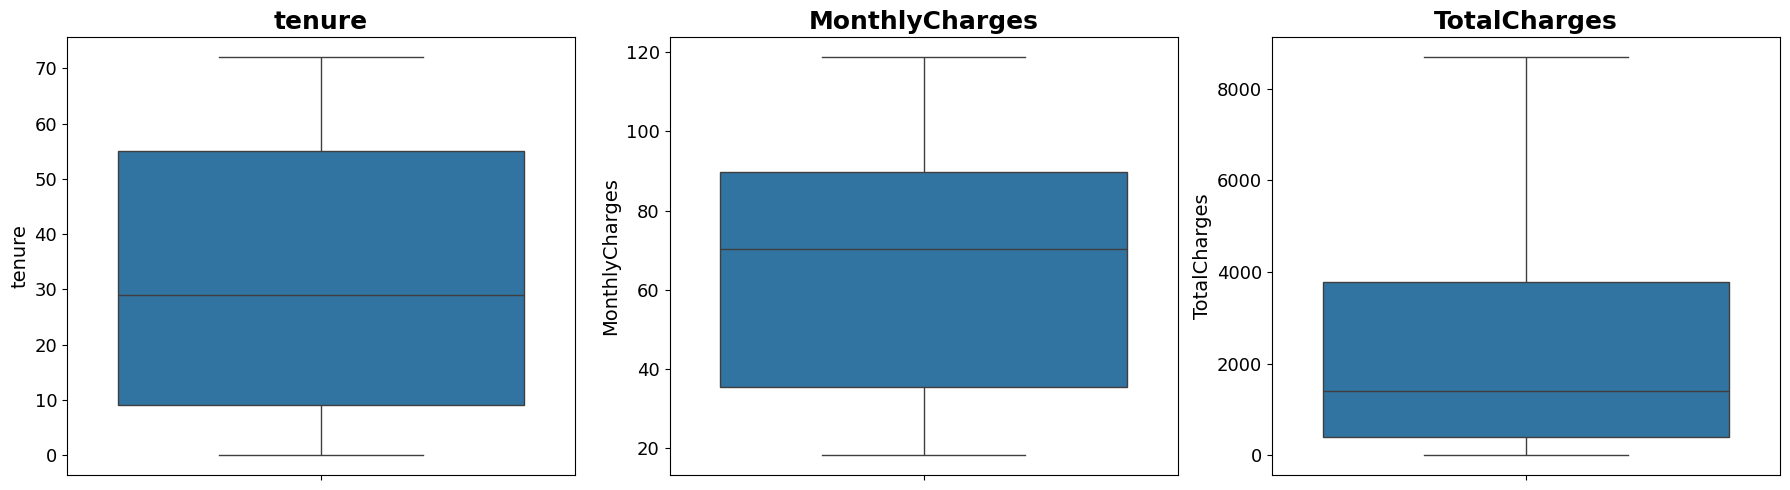

In [226]:
plot_grid(df, num_cols, kind='box')

We observe no anomalies in the distribution of the numeric columns, nor any strange values.

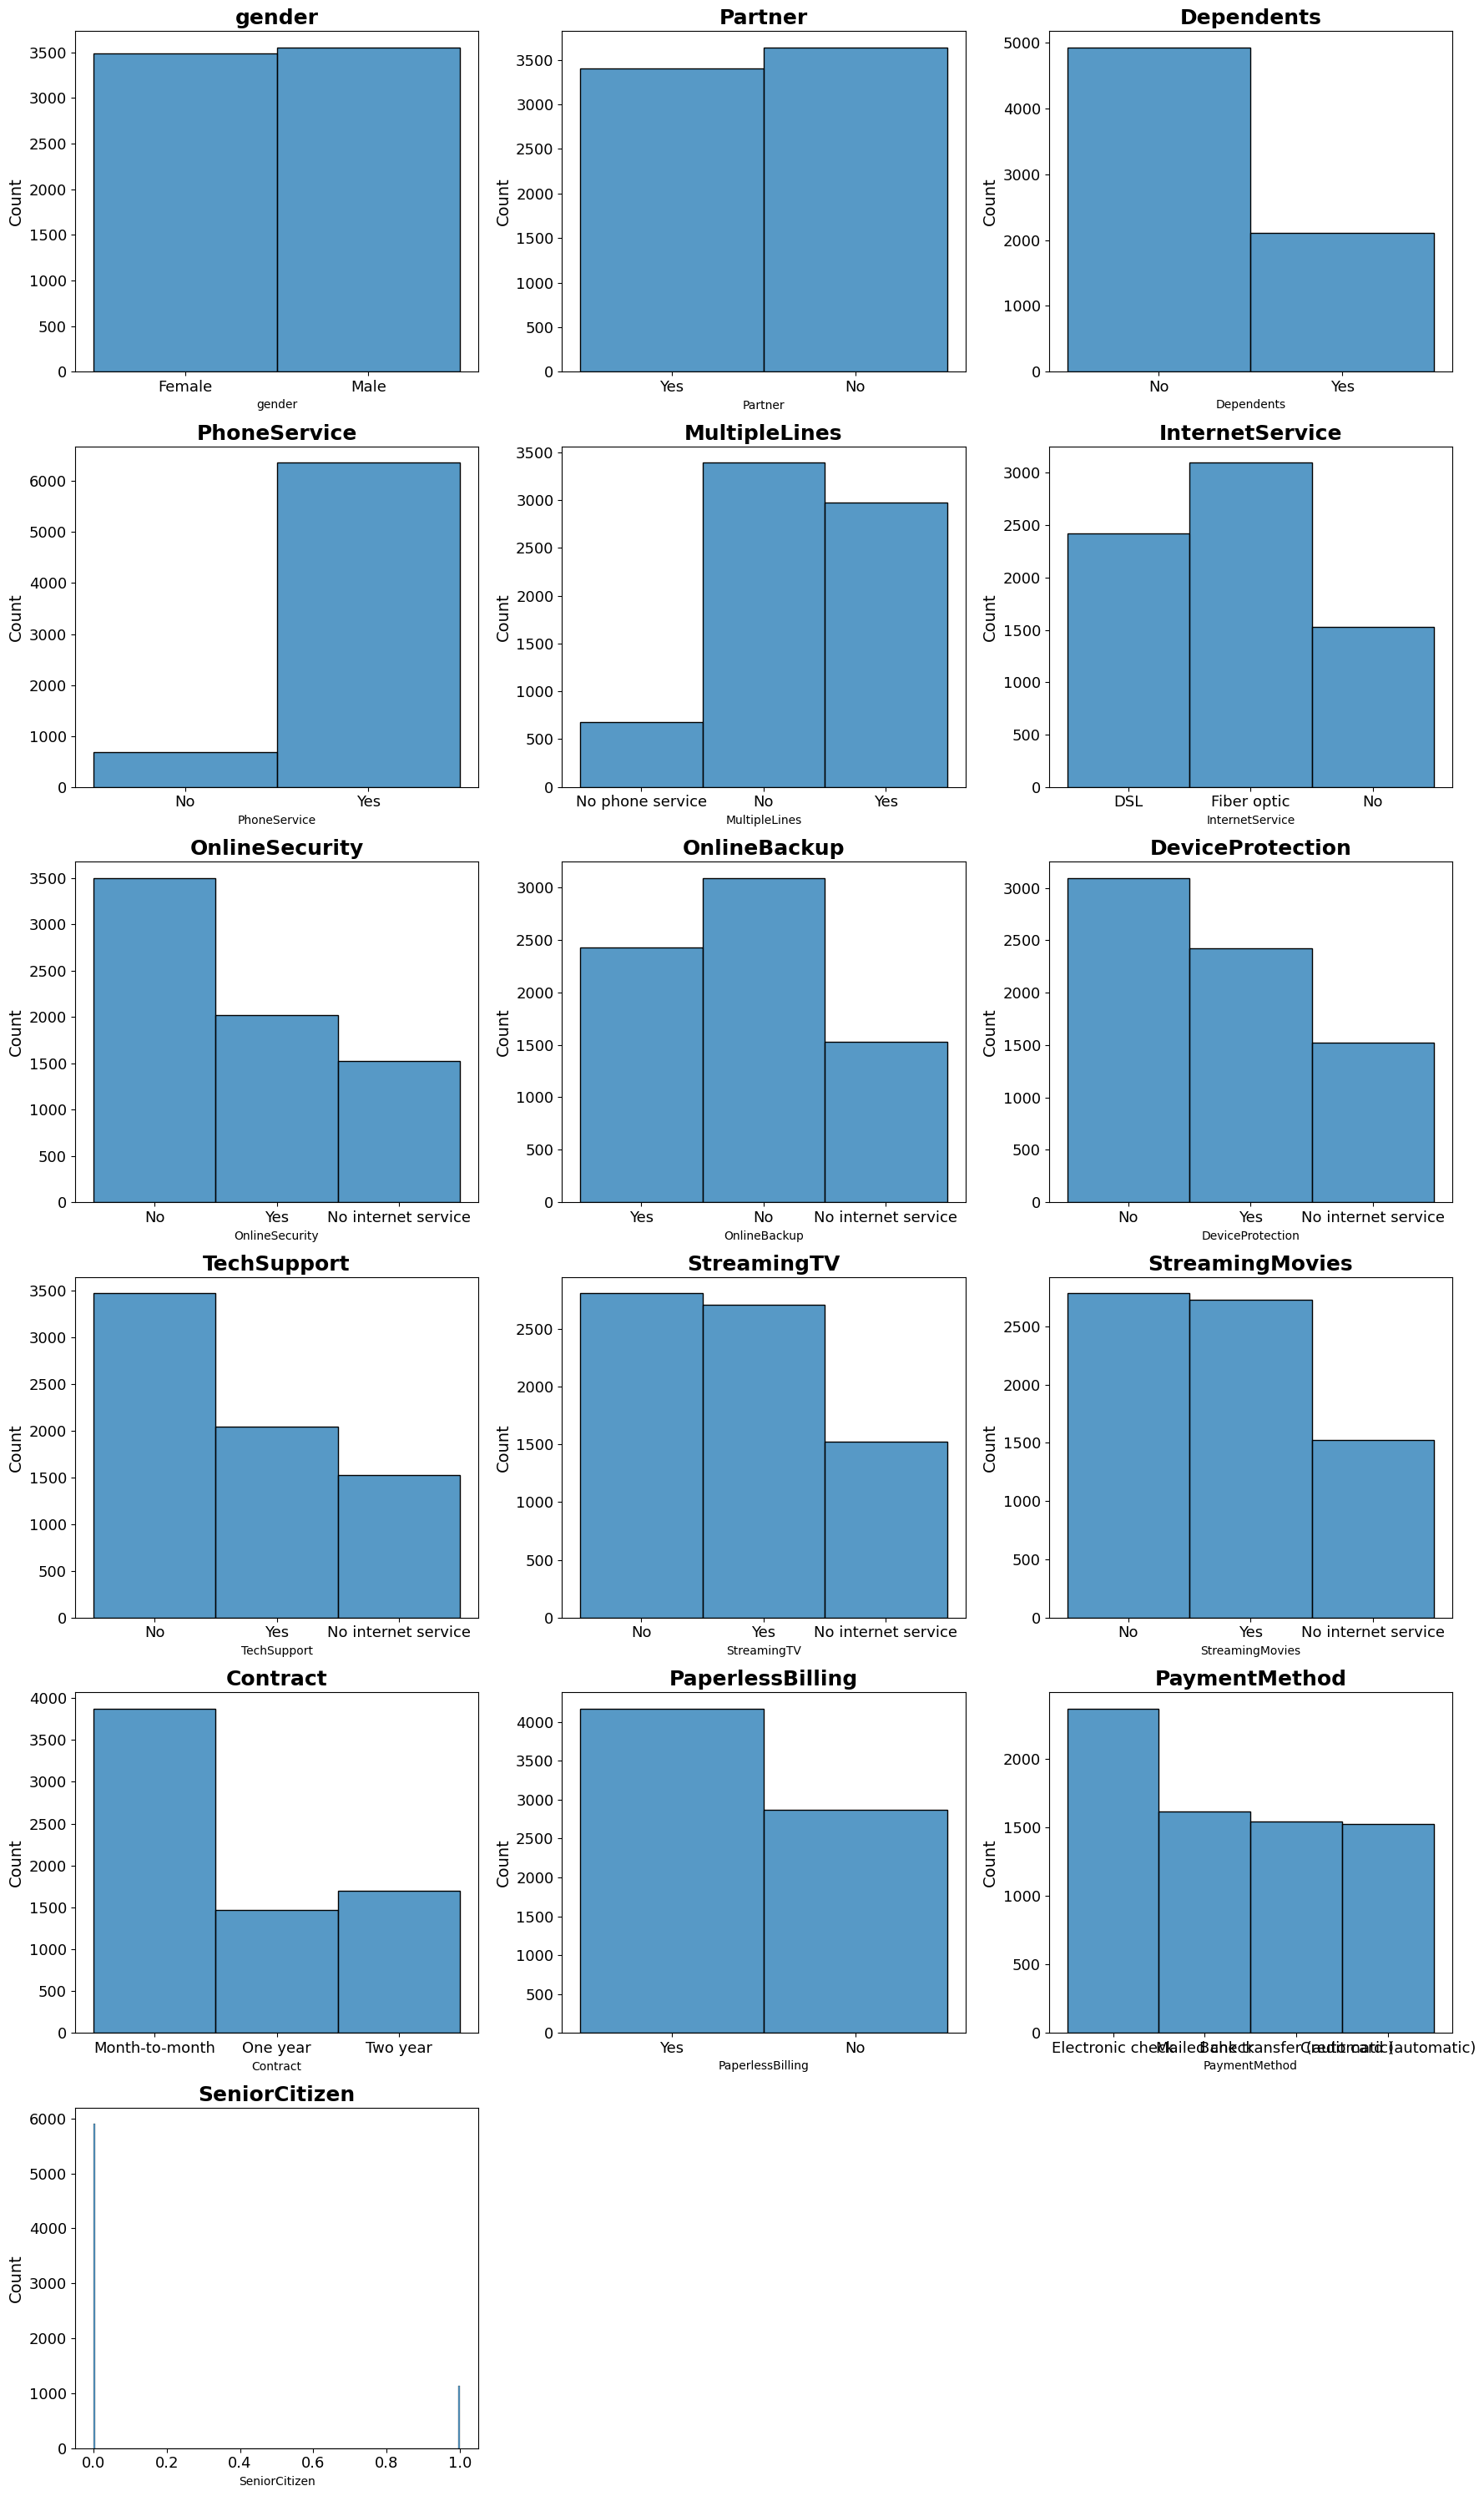

In [227]:
plot_grid(df, cat_cols, kind='hist')

Same conclusion for the univariate analysis of the categorical columns — no anomalies.

## Bivariant analysis

In [228]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Note this is an imbalanced dataset, so we should account for it during modelling (e.g. `class_weight`). It is not imbalanced enough to require SMOTE or other resampling techniques.

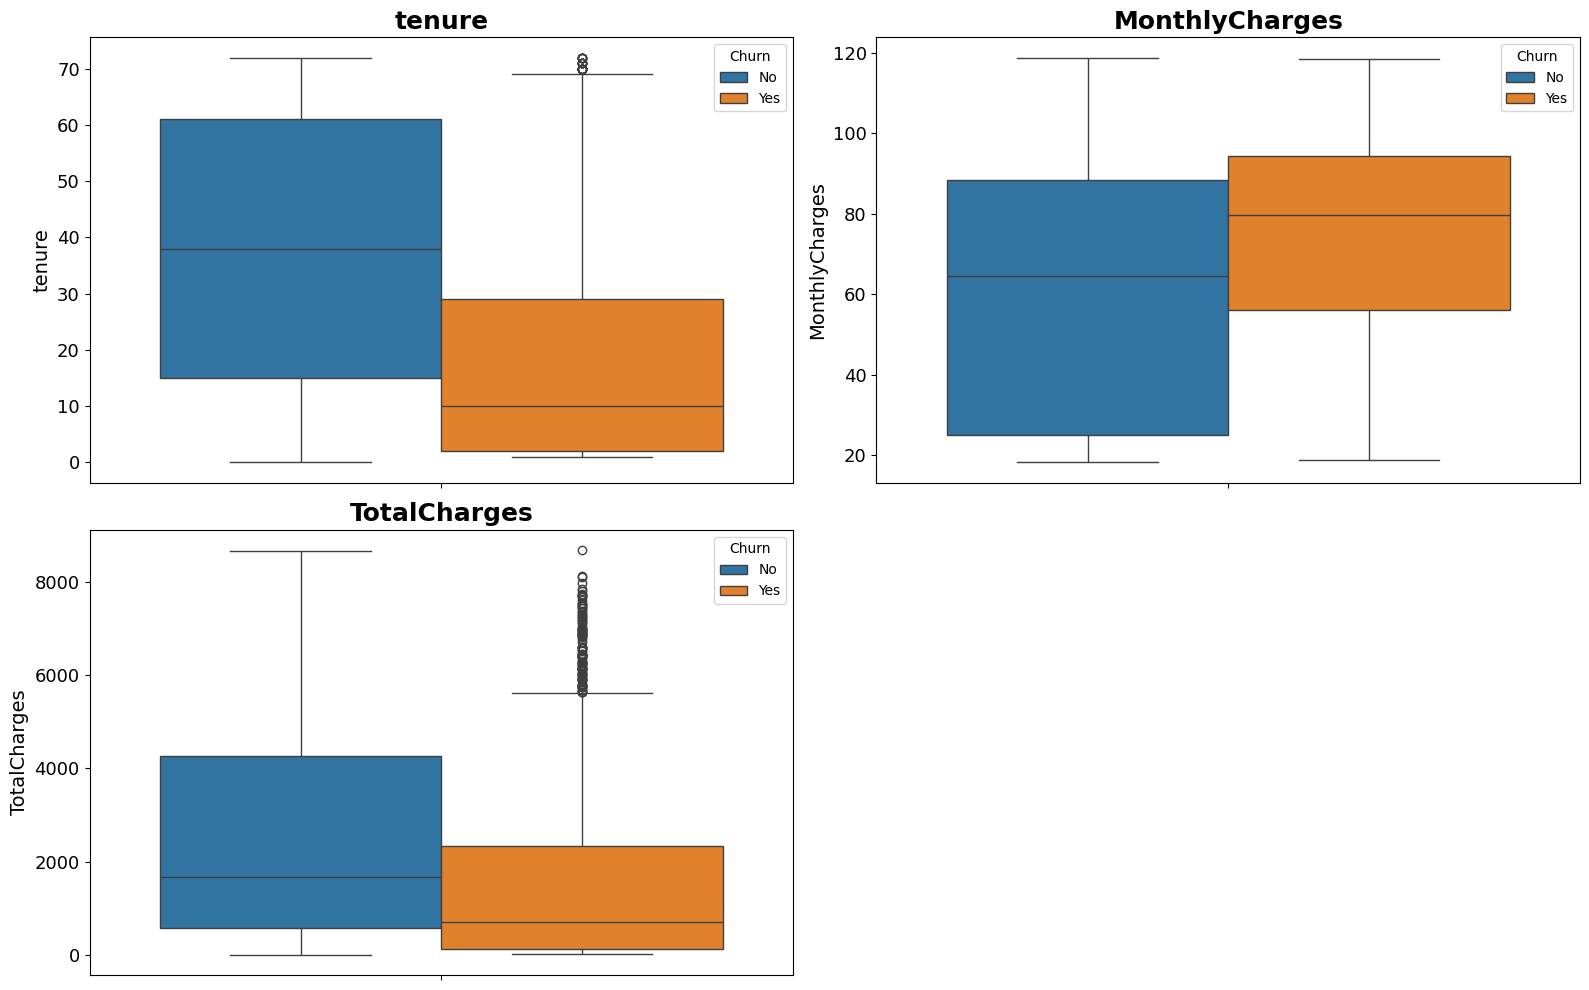

In [229]:
plot_grid(df, num_cols, kind='box_hue', target='Churn', n_cols=2, figsize_per=(8, 5))

Several things can be observed:
- Churners are concentrated at lower `tenure` values.
- Churners tend to have higher `MonthlyCharges`, suggesting price sensitivity as one of the churn drivers.
- `TotalCharges` is clearly higher for non-churners, consistent with the tenure signal. On the churner side there are several outliers with high `TotalCharges` — in a marketing campaign these would be the primary retention target.

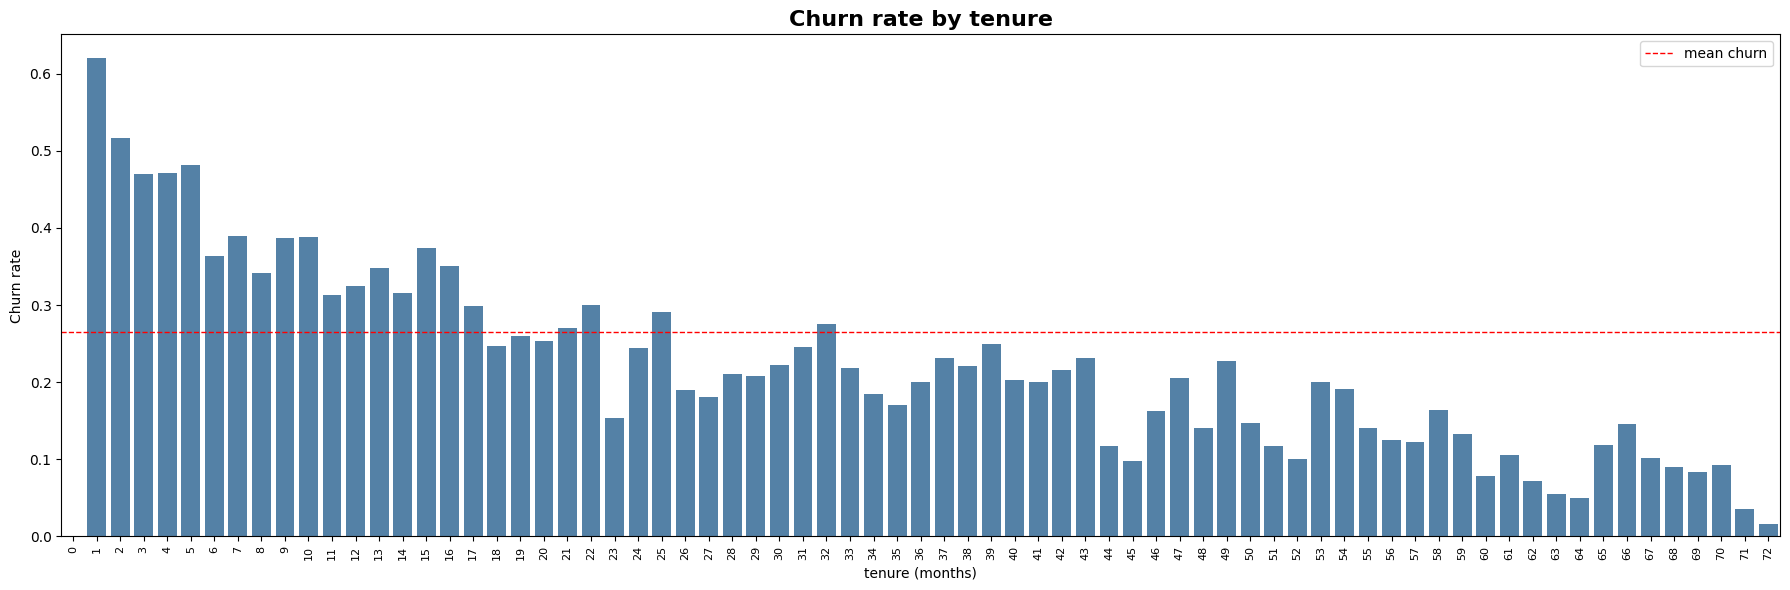

In [230]:
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(18, 6))
sns.barplot(data=df, x='tenure', y='Churn_num', errorbar=None, color='steelblue')
plt.axhline(df['Churn_num'].mean(), color='red', ls='--', lw=1, label='mean churn')
plt.title('Churn rate by tenure', fontsize=16, fontweight='bold')
plt.ylabel('Churn rate')
plt.xlabel('tenure (months)')
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

In [231]:
df['tenure'].max()

np.int64(72)

This feature will later be transformed into a categorical one, grouping tenure values with similar churn ratios. There are many distinct values and, as seen above, the churn decline is not linear.

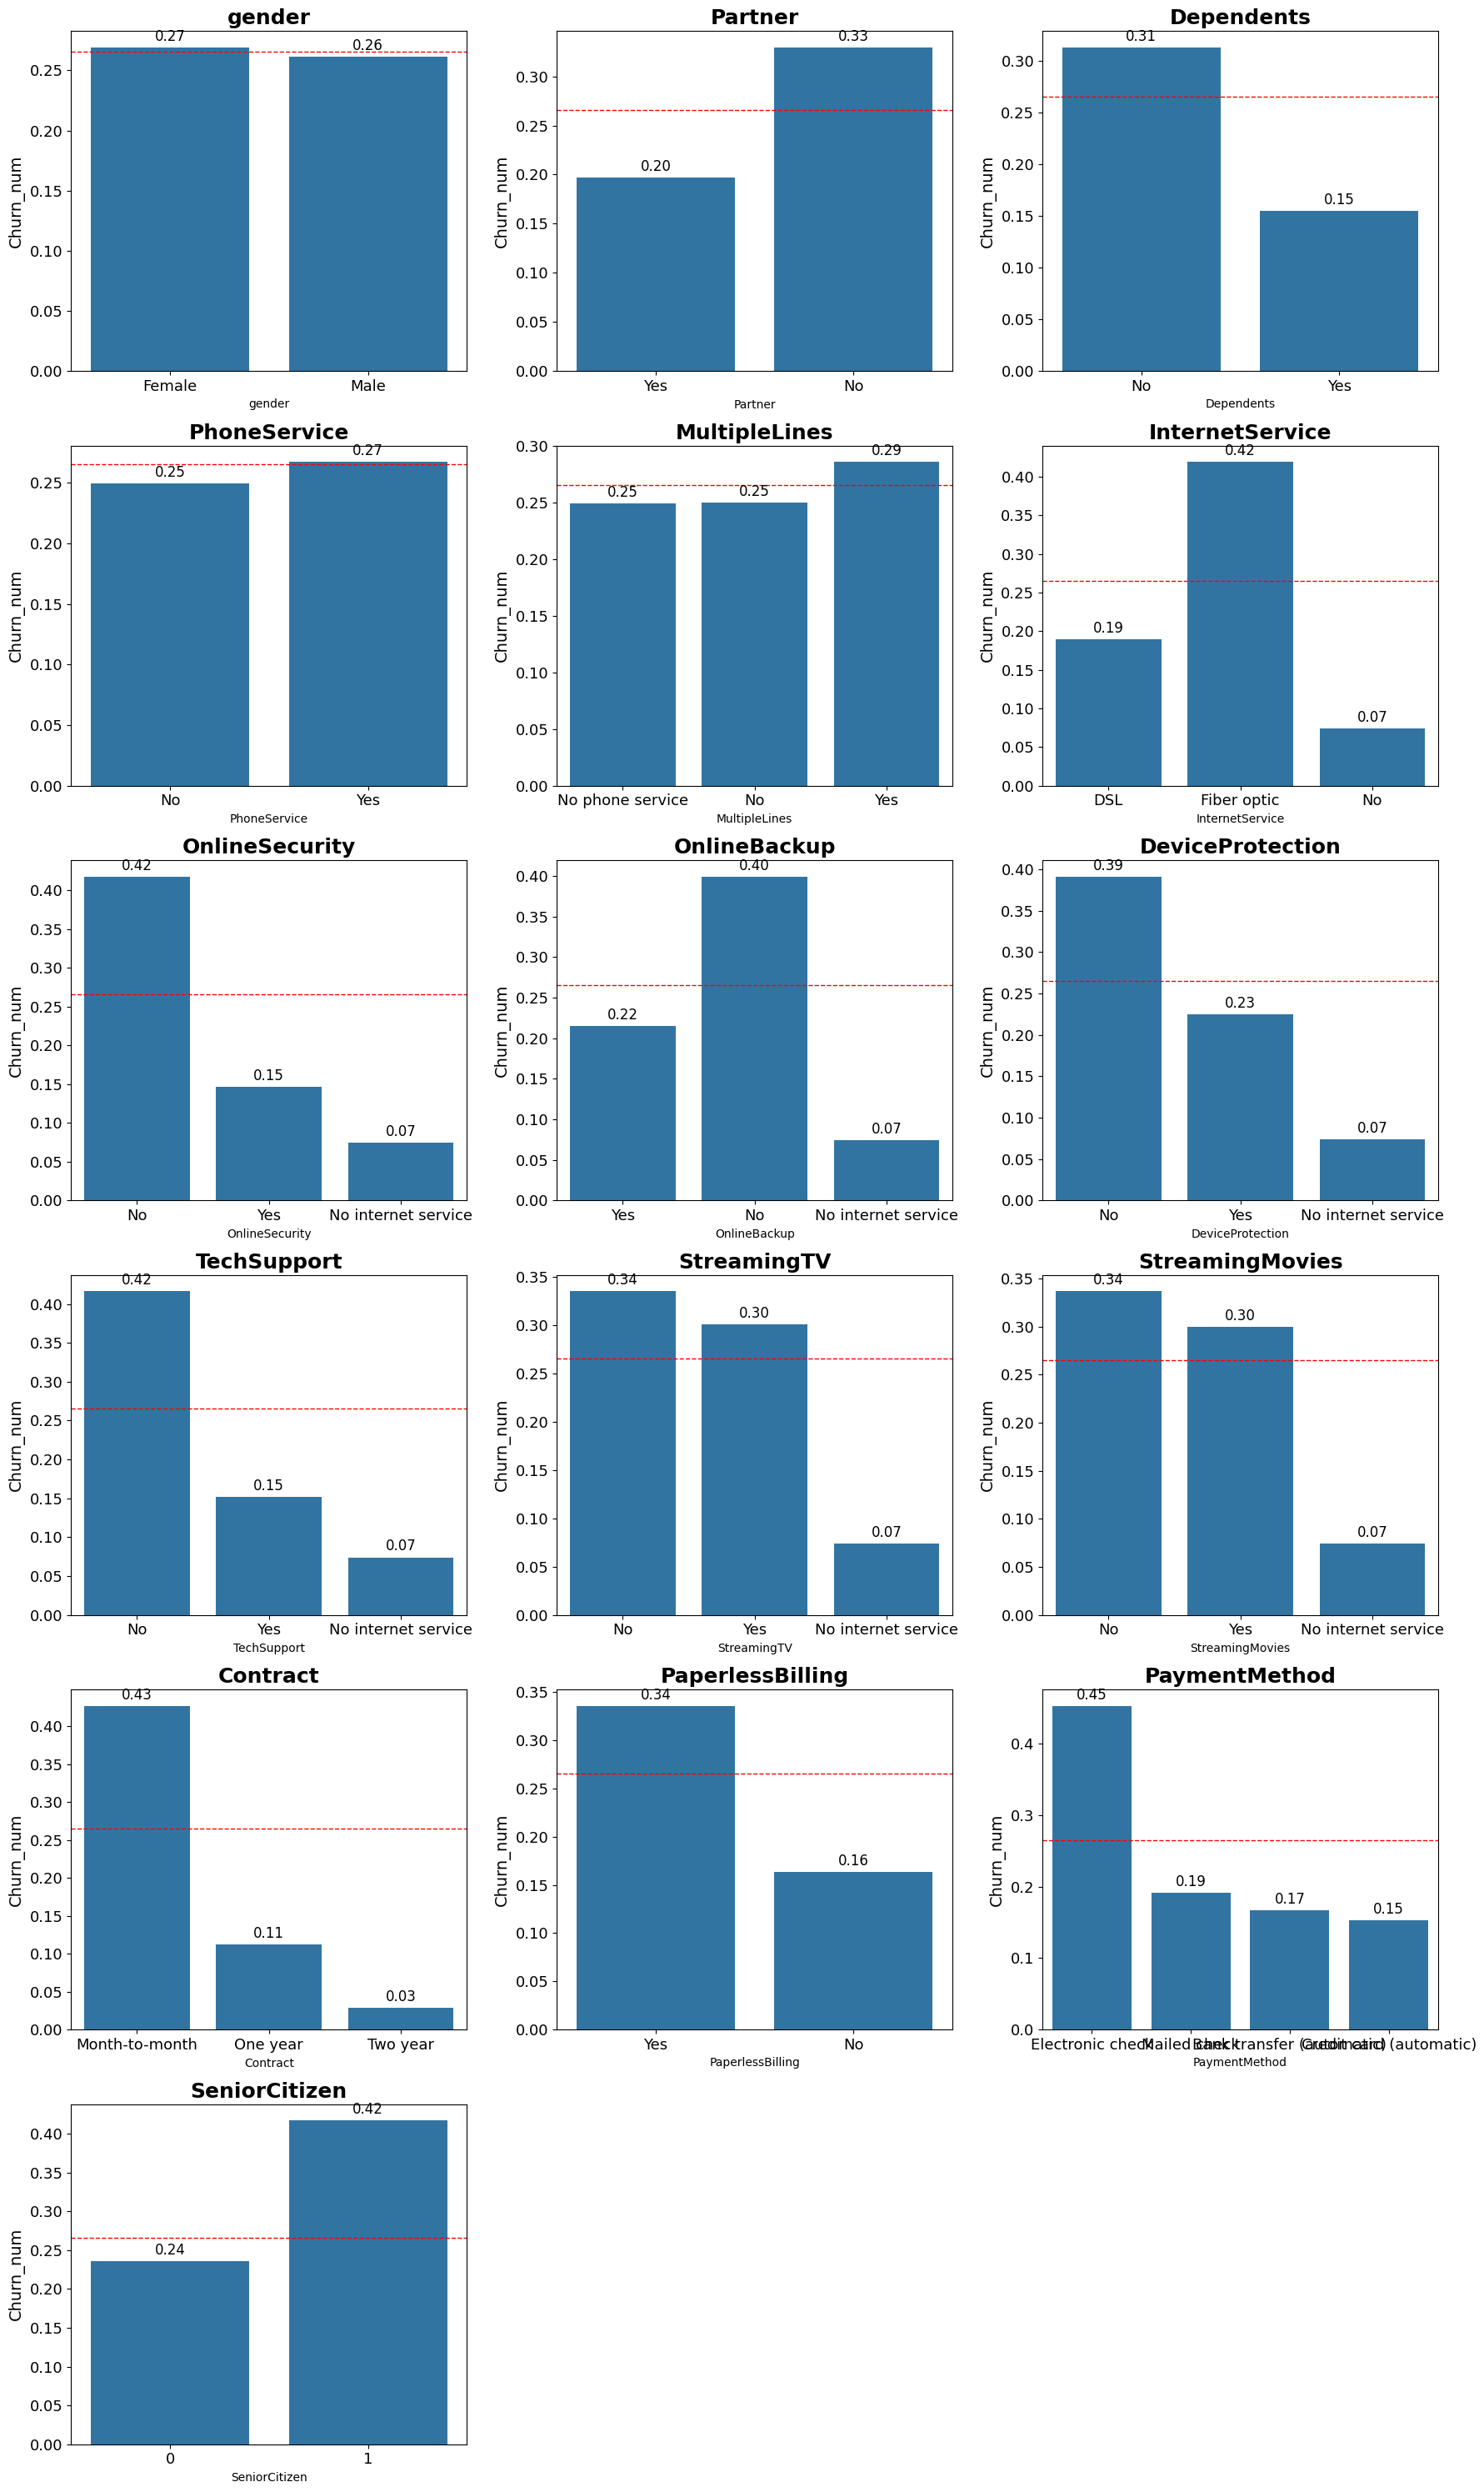

In [232]:
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

plot_grid(df, cat_cols, kind='churn_bar', target='Churn_num')

The `No internet service` category within specific services (e.g. `OnlineBackup`) has a very low churn rate.

This is because it is the same group of customers who have `No` in `InternetService`.

We have three main groups:
- With internet and with additional services (churn higher than the mean)
- With internet and no additional services (churn higher than the no-internet group, but lower than the first group)
- Without internet, and therefore without additional services (low churn)

These three groups are the result of two questions:
- Does the customer have internet?
- Does the customer have additional services?

This can be answered by combining `InternetService` with each service column. There is no need to repeat the `No internet service` category in every specific service — it is redundant information. As long as the model keeps the `InternetService` column, it can reconstruct the three cases.

## Feature Engineering

The main decisions here are:
- Collapse the `No internet service` category in specific services to `No`.
- Create the following new features:
    - `num_services`
    - `tenure` groups: binned brackets, since churn differs clearly across tenure values but not in a linear way.
    - `new_customer`: flag for customers with `tenure == 0`, where churn spikes.

In [233]:
# Clean base for feature engineering: collapse redundant "No * service" categories.
# InternetService still carries the "has internet" signal, so no information is lost.
cols_internet = [c for c in cat_cols if (df[c] == 'No internet service').any()]

df_clean = df.copy()
df_clean[cols_internet] = df_clean[cols_internet].replace('No internet service', 'No')
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

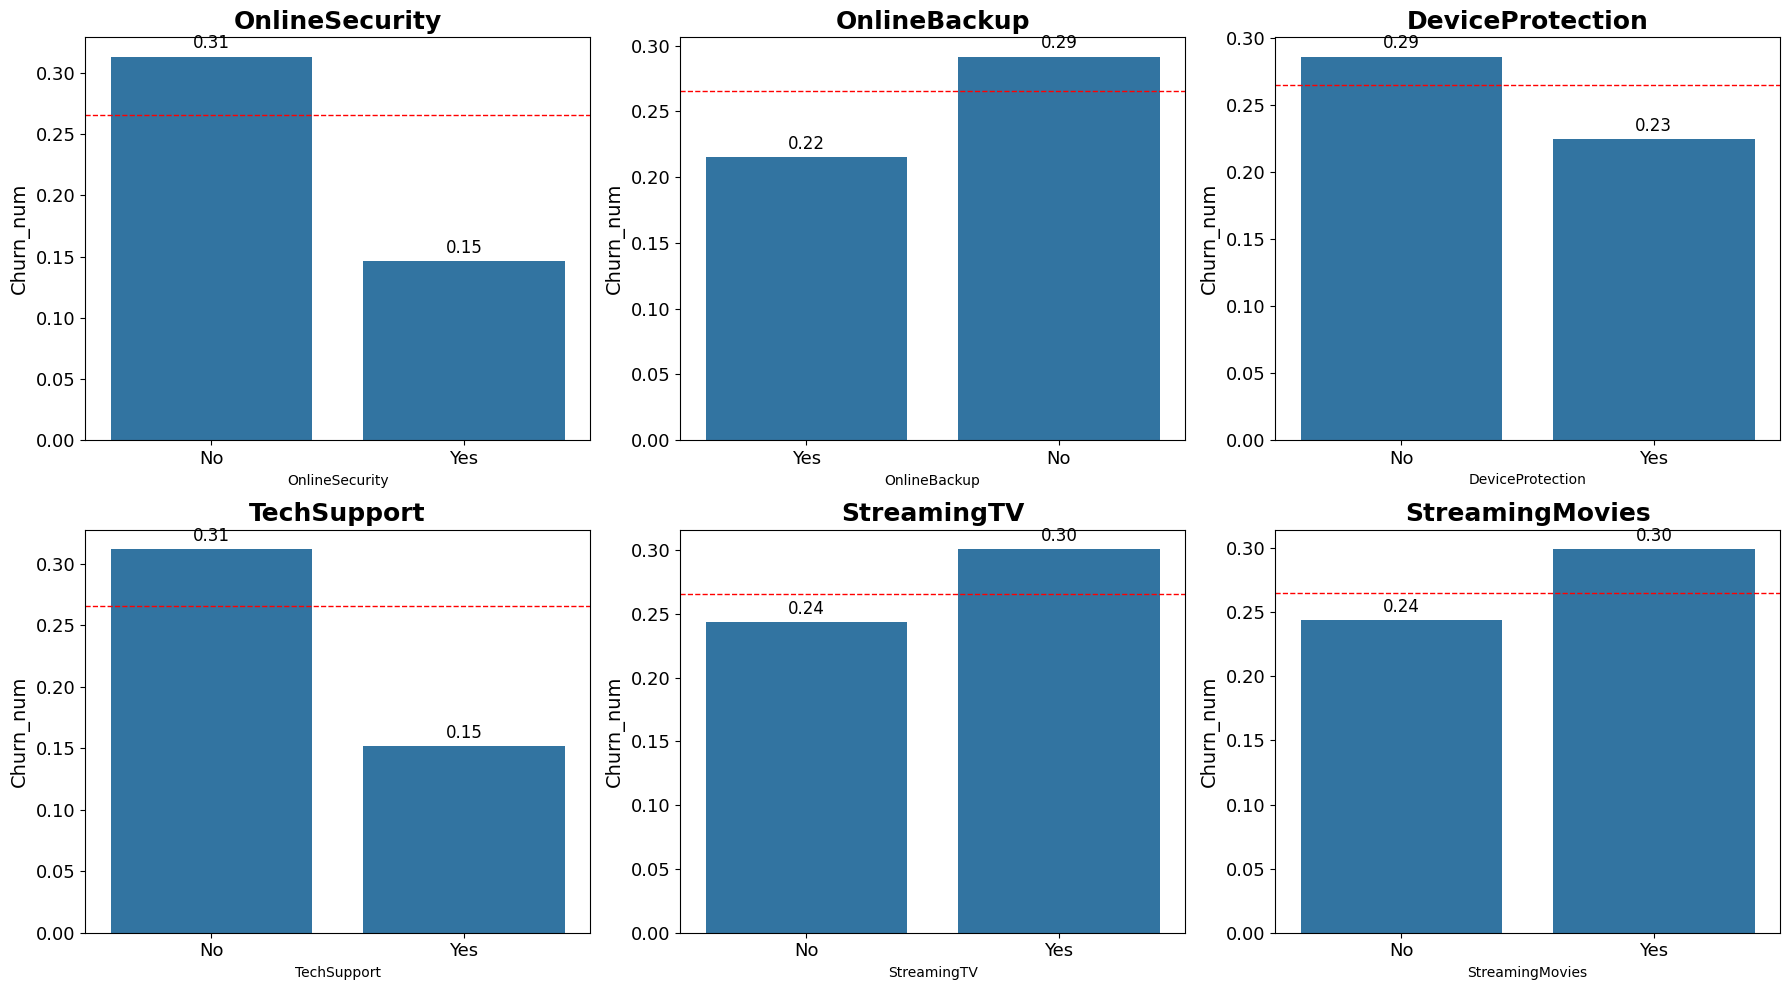

In [234]:
df_clean['Churn_num'] = (df_clean['Churn'] == 'Yes').astype(int)

plot_grid(df_clean, cols_internet, kind='churn_bar', target='Churn_num')

These visualizations are not a source of truth: the churn % for `StreamingMovies`, for example, no longer reflects the reality of that feature (as seen in the previous visualization, the collapsed `No` mixes no-internet customers with internet customers who did not subscribe to that service).

This note is just to stress that these feature-engineering decisions are purely **MODELLING** decisions.

In [235]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [236]:
def create_num_services(d: pd.DataFrame) -> pd.DataFrame:
    """Add `num_services`: the number of services each customer has subscribed to."""
    d = d.copy()
    services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'PhoneService']
    d['num_services'] = (d[services] == 'Yes').sum(axis=1)
    return d


def create_tenure_groups(d: pd.DataFrame) -> pd.DataFrame:
    """Bin `tenure` into churn-risk brackets and flag brand-new customers.

    Brackets (observed churn rate):
        0-5     (54.3%)  initial cliff
        6-17    (35.2%)  steep decline, above the mean
        18-40   (22.8%)  plateau around the mean
        41-60   (15.6%)  second step down
        61-72   ( 6.6%)  loyal long-tenure customers
    """
    d = d.copy()
    d['new_customer'] = np.where(d['tenure'] == 0, 'Yes', 'No')

    bins = [-1, 5, 17, 40, 60, 72]
    labels = ['0-5', '6-17', '18-40', '41-60', '61-72']
    d['tenure'] = pd.cut(d['tenure'], bins=bins, labels=labels, ordered=True)
    assert d['tenure'].notna().all(), "tenure values fall outside the defined bins"
    return d

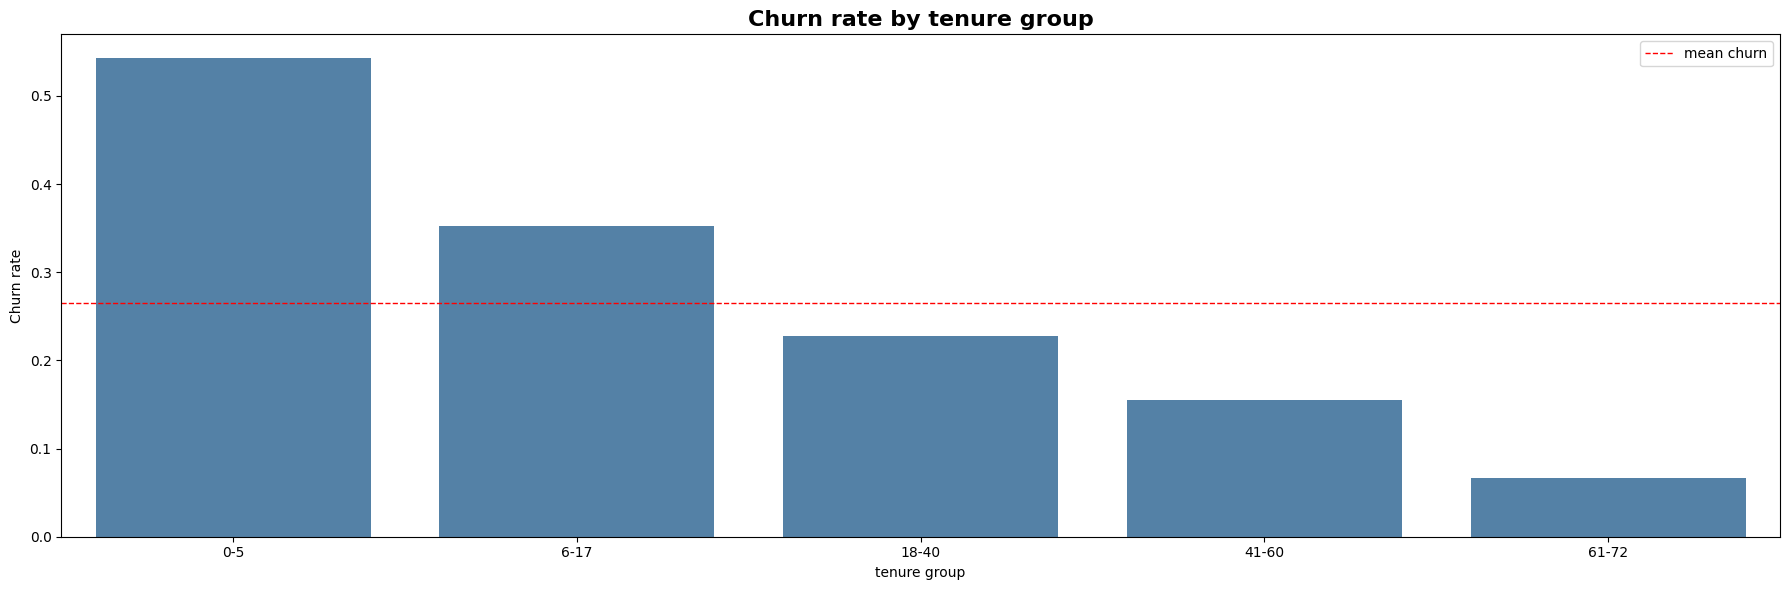

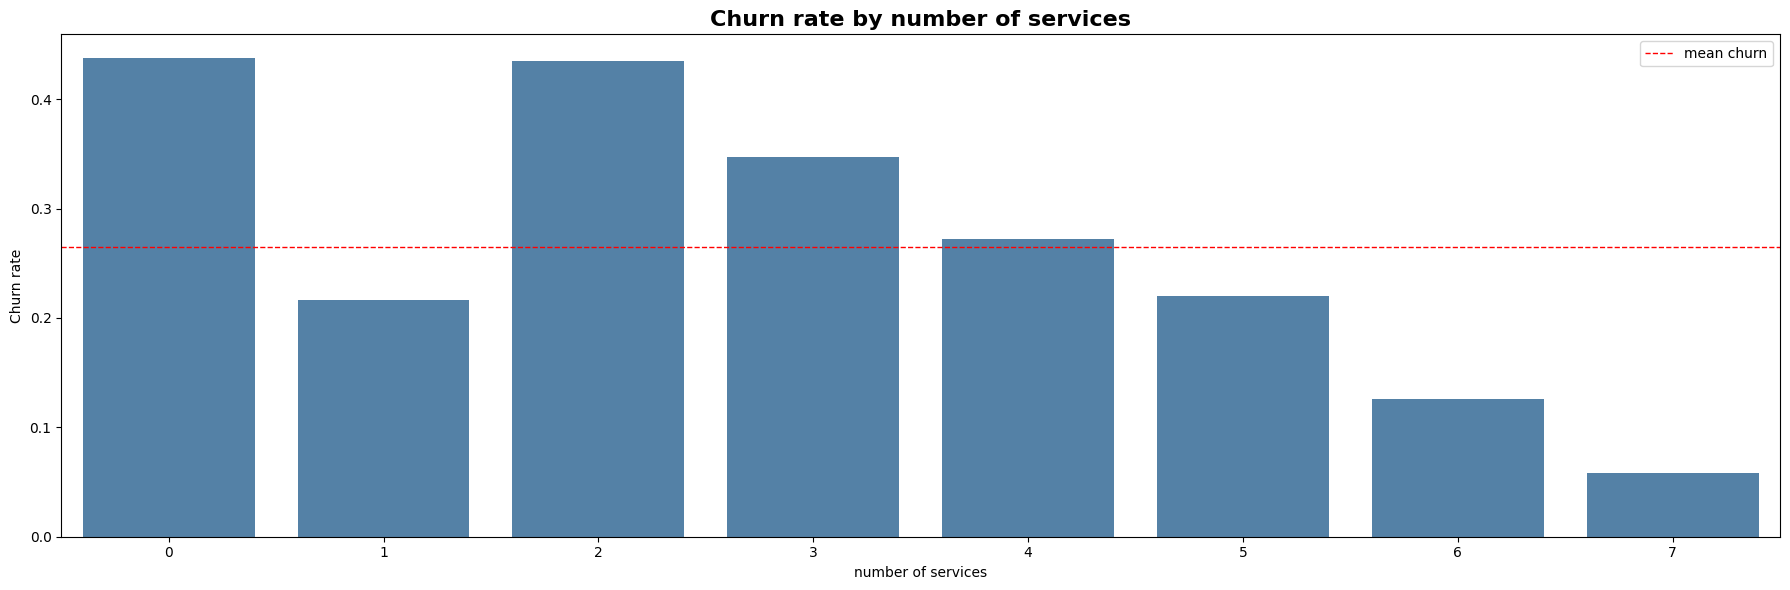

In [237]:
# Build the feature-engineered frame from the clean base.
# Starting from df_clean (not d) keeps this idempotent: re-running is always safe.
d = df_clean.pipe(create_num_services).pipe(create_tenure_groups)

d['Churn_num'] = (d['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(18, 6))
sns.barplot(data=d, x='tenure', y='Churn_num', errorbar=None, color='steelblue')
plt.axhline(d['Churn_num'].mean(), color='red', ls='--', lw=1, label='mean churn')
plt.title('Churn rate by tenure group', fontsize=16, fontweight='bold')
plt.ylabel('Churn rate')
plt.xlabel('tenure group')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
sns.barplot(data=d, x='num_services', y='Churn_num', errorbar=None, color='steelblue')
plt.axhline(d['Churn_num'].mean(), color='red', ls='--', lw=1, label='mean churn')
plt.title('Churn rate by number of services', fontsize=16, fontweight='bold')
plt.ylabel('Churn rate')
plt.xlabel('number of services')
plt.legend()
plt.tight_layout()
plt.show()

In [241]:
d.to_csv('../data/processed/telco_clean.csv', index=False)


## Exploratory correlation

A quick encoding (binary `Yes/No` → `1/0`, one-hot for the rest) purely to explore correlations with churn and among features. This is **not** the final modelling encoding — it just gives a panoramic view. Pearson correlation on binary variables measures linear association, so non-linear effects (e.g. `tenure`) are better read from the churn-rate plots above.

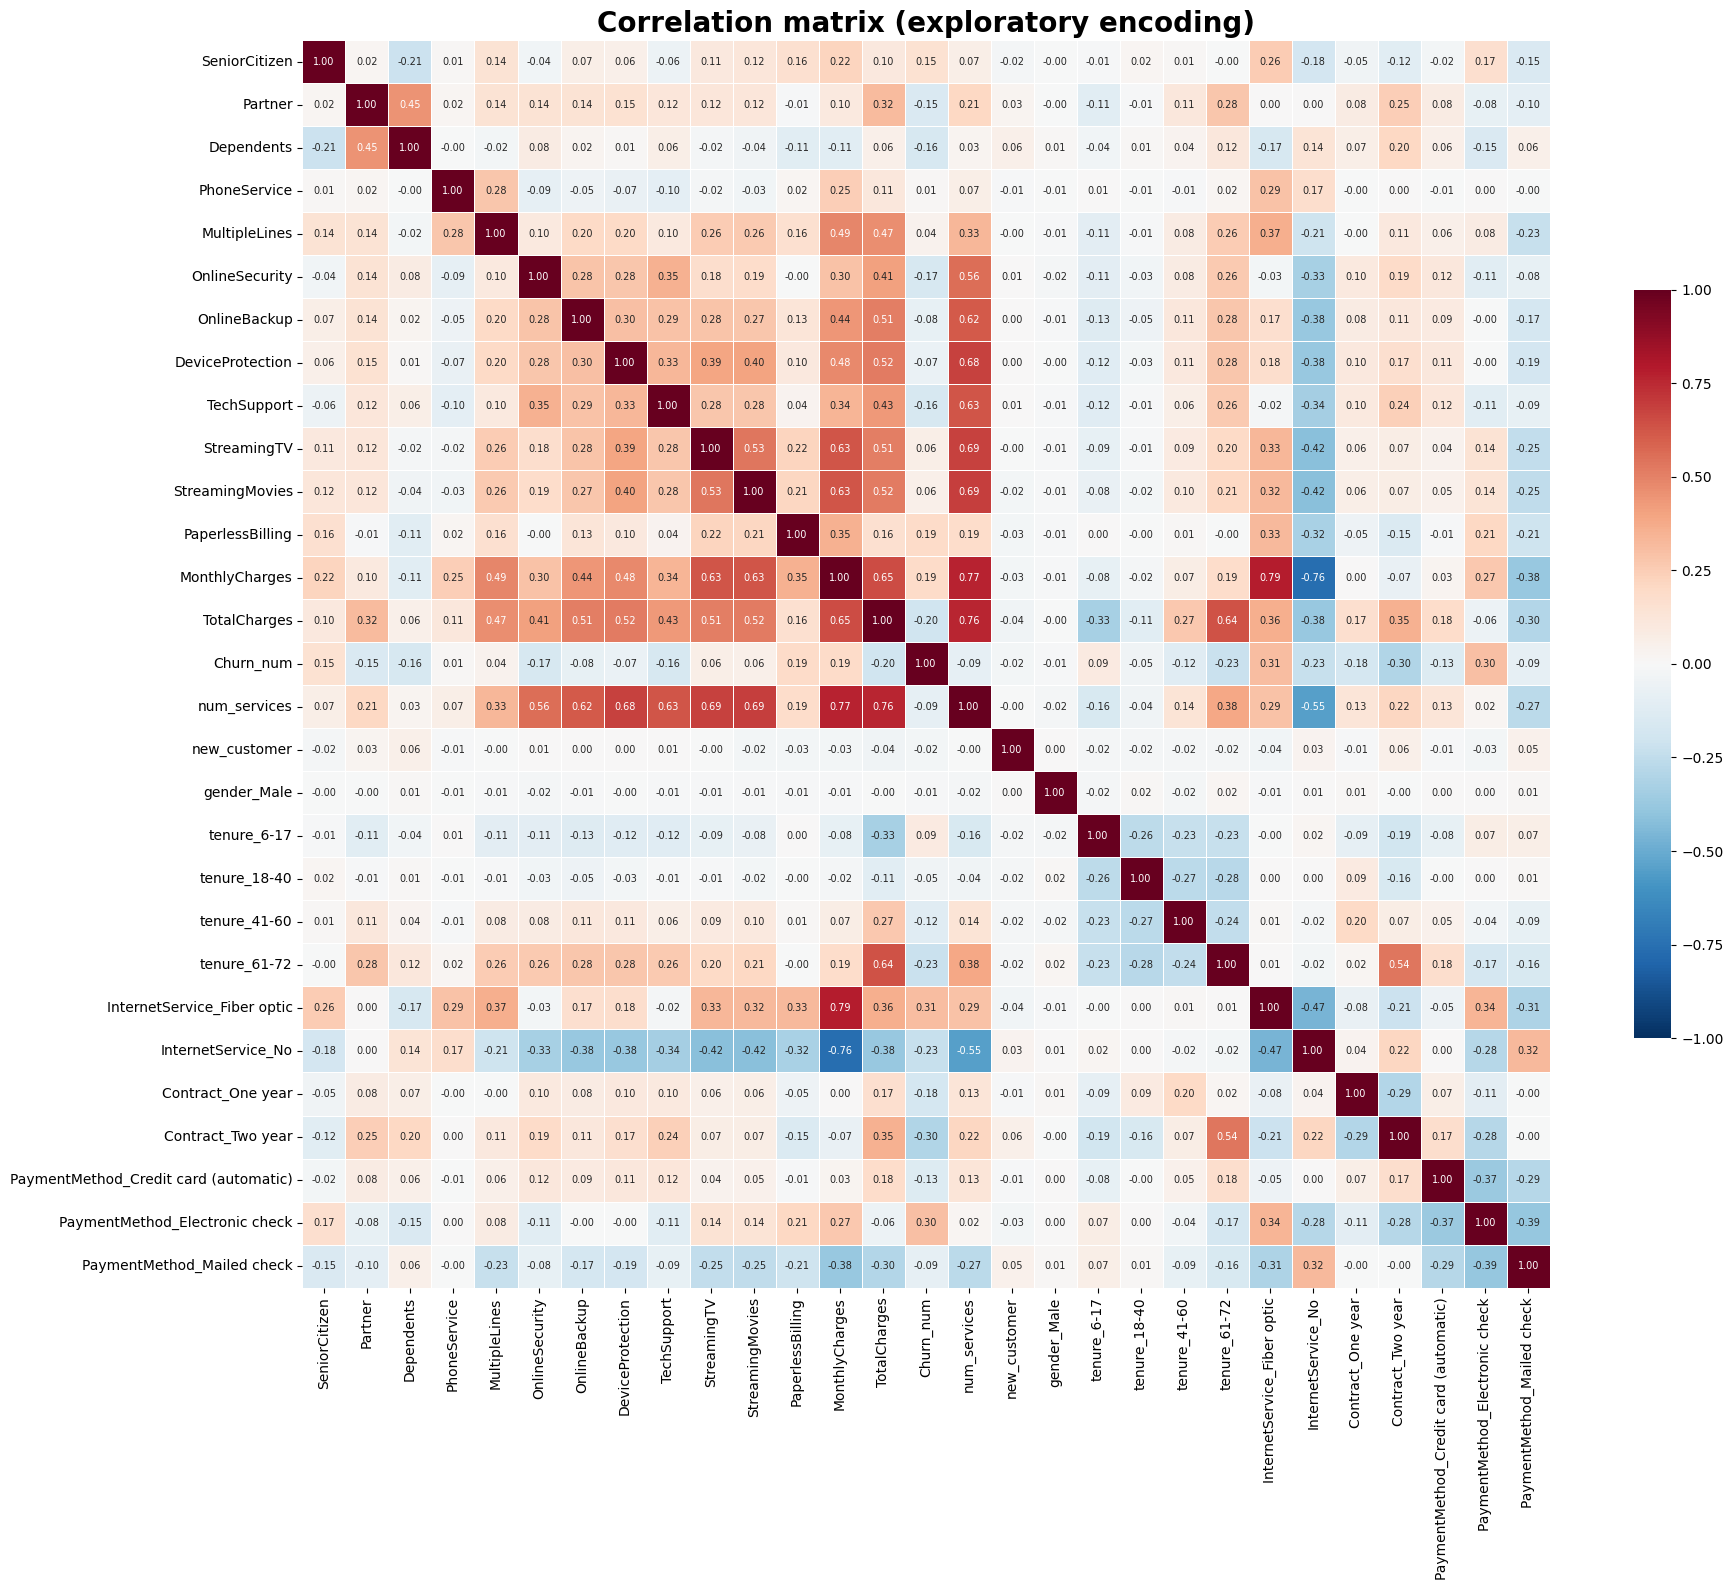

Contract_Two year                       -0.302253
InternetService_No                      -0.227890
tenure_61-72                            -0.225500
TotalCharges                            -0.198324
Contract_One year                       -0.177820
OnlineSecurity                          -0.171226
TechSupport                             -0.164674
Dependents                              -0.164221
Partner                                 -0.150448
PaymentMethod_Credit card (automatic)   -0.134302
tenure_41-60                            -0.121114
PaymentMethod_Mailed check              -0.091683
num_services                            -0.085963
OnlineBackup                            -0.082255
DeviceProtection                        -0.066160
tenure_18-40                            -0.046776
new_customer                            -0.023771
gender_Male                             -0.008612
PhoneService                             0.011942
MultipleLines                            0.040102


In [238]:
corr_df = d.drop(columns=['customerID', 'Churn']).copy()

# binary Yes/No -> 1/0
binary_cols = [c for c in corr_df.columns
               if corr_df[c].dropna().isin(['Yes', 'No']).all()]
corr_df[binary_cols] = (corr_df[binary_cols] == 'Yes').astype(int)

# one-hot for the remaining (multi-class / categorical) columns
multiclass = corr_df.select_dtypes(include=['object', 'string', 'category']).columns
corr_df = pd.get_dummies(corr_df, columns=list(multiclass), drop_first=True)

corr = corr_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.6},
)
plt.title('Correlation matrix (exploratory encoding)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# correlation of every feature with churn, sorted
corr['Churn_num'].drop('Churn_num').sort_values()

**Reading the correlation matrix.** This heatmap was built only for a quick, panoramic glance — it is not the basis for feature selection.

No feature shows a strong linear correlation with the target (the largest are around ±0.30–0.35: `tenure`, `Contract`, `InternetService`, `PaymentMethod`). **This is expected and not a concern**, for several reasons:

- **Pearson on binary variables is bounded low.** Most features here are `0/1`, and the point-biserial/phi correlation rarely reaches high values even when the relationship is strong. For example, `Electronic check` has 45% churn vs 26% overall — a clear driver — yet correlates only ~0.30. The churn-rate-by-group plots above tell the story better than the correlation for these variables.
- **Churn is multifactorial.** No single variable determines it; it is the *combination* (flexible contract + high price + low tenure + fiber + electronic check) that predicts. Hence no single feature correlates strongly — which is exactly why a model is needed instead of a simple rule.
- **Weak individually, strong together.** Many features in the 0.15–0.35 range combine into a model with good predictive power (typical AUC ≈ 0.84 on this dataset). Individual correlation understates the joint signal.
- **Pearson only captures linear association**, missing interactions and non-linearities (the stepwise effect of `tenure`, `InternetService × Contract`, etc.) that the model will exploit.

As a sanity note: a feature correlating **0.9+** with the target would instead be a red flag for **data leakage**. Moderate, spread-out correlations like these are exactly what a well-posed churn problem should show.

## Key findings

**Target:** 26.5% churn — imbalanced, but not severely (use `class_weight`, no resampling needed).

**Main churn drivers:**
- **Contract:** month-to-month customers churn far more than 1- or 2-year contracts.
- **Tenure:** churn is highest in the first months (54% at 0–5) and drops monotonically to ~7% for long-tenure customers — the strongest single signal.
- **Internet service:** fiber-optic churns at 42% vs 19% DSL and 7% no internet, likely confounded with price and contract type.
- **Payment method:** electronic check stands out at 45% churn vs ~15–19% for the rest.
- **Add-on services:** having security / tech support / backup roughly halves churn among internet users; `num_services` captures this stickiness.
- **Monthly charges:** churners tend to pay more (price sensitivity).

**Data quality:** 11 blank `TotalCharges` = new customers (`tenure` 0), imputed to 0. No duplicate rows, `customerID` unique. No outliers of concern.

**Feature-engineering decisions:**
- Collapse `No internet/phone service` → `No` (redundant given `InternetService`), keeping `InternetService` for the signal.
- Created `num_services`, `new_customer`, and binned `tenure`.
- These are modelling decisions; univariate plots on collapsed data can mislead.

**Next steps:** build the encoding pipeline (ordinal for ordered categories such as `tenure` and `Contract`, one-hot for nominal ones) → check multicollinearity (`tenure` × `MonthlyCharges` ≈ `TotalCharges`) → train a churn model with class weights.